In [1]:
from pathlib import Path
from typing import Optional, List, Tuple
import gc
import pickle
import sys
import types
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import subprocess

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

In [2]:
BASE_DIR = Path("jr-test") if Path("jr-test").exists() else Path(".")
ARTIFACT_DIR = BASE_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

SEQ_LEN = 512
BATCH_SIZE = 32
EPOCHS = 100
RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

KOI_LABEL_MAP_PATH = ARTIFACT_DIR / "koi_label_map.csv"
COMBINED_X_PATH = ARTIFACT_DIR / "combined_X.npy"
COMBINED_Y_PATH = ARTIFACT_DIR / "combined_y.npy"
COMBINED_META_PATH = ARTIFACT_DIR / "combined_metadata.csv"
CLASSES_PATH = ARTIFACT_DIR / "combined_classes.npy"
EXPERIMENT_CONFIGS = [
    {
        "name": "model1",
        "label": "Model 1",
        "hidden_size": 96,
        "num_layers": 2,
        "dropout": 0.20,
        "lr": 5e-4,
        "weight_decay": 1e-4,
        "model_path": ARTIFACT_DIR / "lstm_model1.pt",
        "predictions_path": ARTIFACT_DIR / "test_predictions_lstm_model1.csv",
    },
    {
        "name": "model2",
        "label": "Model 2",
        "hidden_size": 128,
        "num_layers": 3,
        "dropout": 0.30,
        "lr": 3e-4,
        "weight_decay": 5e-5,
        "model_path": ARTIFACT_DIR / "lstm_model2.pt",
        "predictions_path": ARTIFACT_DIR / "test_predictions_lstm_model2.csv",
    },
    {
        "name": "model3",
        "label": "Model 3",
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.10,
        "lr": 7e-4,
        "weight_decay": 1e-5,
        "model_path": ARTIFACT_DIR / "lstm_model3.pt",
        "predictions_path": ARTIFACT_DIR / "test_predictions_lstm_model3.csv",
    },
]

In [3]:
print(f"Base directory: {BASE_DIR.resolve()}")
print(f"Artifact directory: {ARTIFACT_DIR.resolve()}")
print(f"Device: {DEVICE}")

Base directory: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test
Artifact directory: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts
Device: cpu


In [4]:
PROCESS_SCRIPT = BASE_DIR / "process_dataset_artifact.py"
SUBPROCESS_PYTHON = Path("/Users/jithinrajan/miniconda3/bin/python")
if not SUBPROCESS_PYTHON.exists():
    SUBPROCESS_PYTHON = Path(sys.executable)

In [5]:
def run_processing_subprocess(dataset_name: str) -> None:
    cmd = [str(SUBPROCESS_PYTHON), str(PROCESS_SCRIPT), "--dataset", dataset_name]
    print("Running:", " ".join(cmd))
    result = subprocess.run(
        cmd,
        cwd=str(BASE_DIR.parent if BASE_DIR.name == "jr-test" else BASE_DIR),
        capture_output=True,
        text=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"Processing subprocess failed for {dataset_name} with exit code {result.returncode}")

In [6]:
def ensure_numpy_pickle_compat() -> None:
    aliases = {
        "numpy._core": "numpy.core",
        "numpy._core.numeric": "numpy.core.numeric",
        "numpy._core.multiarray": "numpy.core.multiarray",
        "numpy._core.umath": "numpy.core.umath",
        "numpy._core._multiarray_umath": "numpy.core._multiarray_umath",
    }
    for old_name, new_name in aliases.items():
        if old_name not in sys.modules:
            sys.modules[old_name] = __import__(new_name, fromlist=["*"])

In [7]:
class _LegacyStringArrayCompat:
    def __init__(self) -> None:
        self.data = None

    def __setstate__(self, state) -> None:
        if isinstance(state, tuple) and len(state) == 2:
            self.data = np.asarray(state[1], dtype=object)
        else:
            self.data = np.asarray(state, dtype=object)

    def __len__(self) -> int:
        return len(self.data)

    def __iter__(self):
        return iter(self.data)

    def __array__(self, dtype=None):
        return np.asarray(self.data, dtype=dtype)

    @property
    def dtype(self):
        return object

In [8]:
class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if (module, name) == ("pandas._libs.arrays", "__pyx_unpickle_NDArrayBacked"):
            def custom(cls, checksum, state):
                return _LegacyStringArrayCompat()

            return custom
        return super().find_class(module, name)

In [9]:
def read_pickle_compat(path: Path) -> pd.DataFrame:
    ensure_numpy_pickle_compat()
    try:
        df = pd.read_pickle(path)
    except NotImplementedError as exc:
        if "NDArrayBacked" not in str(exc) and "StringDtype" not in str(exc) and "array([" not in str(exc):
            raise
        with open(path, "rb") as fh:
            df = _CompatUnpickler(fh).load()
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Expected DataFrame in {path}, got {type(df)}")
    return df

In [10]:
def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    if "KIC" not in df.columns and df.index.name == "KIC":
        df = df.reset_index()
    if "# ID" not in df.columns and df.index.name == "# ID":
        df = df.reset_index()
    return df

In [11]:
def infer_id_column(df: pd.DataFrame) -> str:
    for col in ["KIC", "kepid", "# ID", "id"]:
        if col in df.columns:
            return col
    raise KeyError(f"No ID column found in columns: {list(df.columns)}")

def infer_flux_column(df: pd.DataFrame) -> str:
    for col in ["detflux", "flux", "PDCSAP_FLUX"]:
        if col in df.columns:
            return col
    raise KeyError(f"No flux column found in columns: {list(df.columns)}")

def infer_label_column(df: pd.DataFrame) -> str:
    for col in ["Class", "class", "label", "Label"]:
        if col in df.columns:
            return col
    raise KeyError(f"No label column found in columns: {list(df.columns)}")

In [12]:
def to_float_array(values) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float32).reshape(-1)
    return arr[np.isfinite(arr)]


def resample_sequence(values: np.ndarray, fixed_len: int = SEQ_LEN) -> np.ndarray:
    values = to_float_array(values)
    if len(values) == 0:
        return np.zeros(fixed_len, dtype=np.float32)
    if len(values) == 1:
        return np.repeat(values, fixed_len).astype(np.float32)

    x_old = np.linspace(0.0, 1.0, len(values), dtype=np.float32)
    x_new = np.linspace(0.0, 1.0, fixed_len, dtype=np.float32)
    seq = np.interp(x_new, x_old, values).astype(np.float32)

    mean = float(seq.mean())
    std = float(seq.std())
    if std < 1e-6:
        return (seq - mean).astype(np.float32)
    return ((seq - mean) / std).astype(np.float32)

In [13]:
def build_sequence(group: pd.DataFrame, flux_col: str) -> np.ndarray:
    if "quarter" in group.columns:
        group = group.sort_values("quarter")

    parts = []
    for _, row in group.iterrows():
        arr = to_float_array(row[flux_col])
        if len(arr) > 0:
            parts.append(arr)

    if not parts:
        return np.zeros(SEQ_LEN, dtype=np.float32)

    return resample_sequence(np.concatenate(parts), fixed_len=SEQ_LEN)


def remap_label(label: str) -> Optional[str]:
    normalized = str(label).strip().upper()
    mapping = {
        "CONFIRMED": "confirmed",
        "FALSE POSITIVE": "false positives",
        "CANDIDATE": None,
        "NOISE": "false positives",
        "EA": "eclipsing binary",
        "EB": "eclipsing binary",
        "BINARY": "eclipsing binary",
        "GDOR": "variable stars",
        "RRAB": "variable stars",
        "OTHPER": "variable stars",
        "DSCUT": "variable stars",
    }
    return mapping.get(normalized, None)

In [14]:
def read_koi_catalog_labels(csv_path: Path) -> pd.Series:
    catalog = pd.read_csv(csv_path, comment="#")
    catalog["kepid"] = pd.to_numeric(catalog["kepid"], errors="coerce").astype("Int64")
    catalog["koi_disposition"] = catalog["koi_disposition"].astype(str).str.strip().str.upper()
    catalog = catalog.dropna(subset=["kepid", "koi_disposition"])

    priority = ["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]

    def collapse(group: pd.Series) -> Optional[str]:
        values = set(group.tolist())
        for label in priority:
            if label in values:
                return label
        return None

    label_map = catalog.groupby("kepid")["koi_disposition"].apply(collapse).dropna()
    label_map.index = label_map.index.astype(int)
    return label_map


def dataset_artifact_paths(dataset_name: str) -> Tuple[Path, Path]:
    return ARTIFACT_DIR / f"{dataset_name}_X.npy", ARTIFACT_DIR / f"{dataset_name}_meta.csv"

In [15]:
def process_and_save_dataset(pickle_path: Path, dataset_name: str, koi_label_map: Optional[pd.Series] = None) -> Tuple[Path, Path]:
    print(f"Loading {pickle_path.name} ...")
    df = normalize_dataframe(read_pickle_compat(pickle_path))
    id_col = infer_id_column(df)
    flux_col = infer_flux_column(df)
    label_col = infer_label_column(df) if dataset_name == "c00" else None

    keep_cols = [id_col, flux_col]
    if "quarter" in df.columns:
        keep_cols.append("quarter")
    if label_col is not None:
        keep_cols.append(label_col)
    df = df[keep_cols].copy()

    df[id_col] = pd.to_numeric(df[id_col], errors="coerce")
    df = df.dropna(subset=[id_col]).copy()
    df[id_col] = df[id_col].astype(int)

    sequences = []
    records = []

    grouped = df.groupby(id_col, sort=False)
    total_groups = grouped.ngroups
    print(f"Groups to process: {total_groups}")

    for idx, (object_id, group) in enumerate(grouped, start=1):
        if dataset_name == "villanova":
            label = "binary"
        elif dataset_name == "koi":
            if koi_label_map is None or object_id not in koi_label_map.index:
                continue
            label = str(koi_label_map.loc[object_id]).strip().upper()
        elif dataset_name == "c00":
            label = str(group[label_col].iloc[0]).strip()
        else:
            raise ValueError(f"Unsupported dataset name: {dataset_name}")

        label = remap_label(label)

        if label is None or label == "" or label.lower() == "nan":
            continue

        sequences.append(build_sequence(group, flux_col))
        records.append({"dataset": dataset_name, "object_id": object_id, "label": label})

        if idx % 2000 == 0:
            print(f"Processed {idx}/{total_groups} groups")

    if not sequences:
        raise RuntimeError(f"No sequences generated from {pickle_path}")

    X = np.stack(sequences).astype(np.float32)
    meta = pd.DataFrame(records)
    x_path, meta_path = dataset_artifact_paths(dataset_name)
    np.save(x_path, X)
    meta.to_csv(meta_path, index=False)

    print(f"Saved {dataset_name} sequences: {x_path}")
    print(f"Saved {dataset_name} metadata: {meta_path}")
    print(f"Shape: {X.shape}")
    print(meta['label'].value_counts())

    del df, grouped, sequences, records, X, meta
    gc.collect()
    return x_path, meta_path

In [16]:
class IndexedSequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, indices: np.ndarray):
        self.X = X
        self.y = y
        self.indices = np.asarray(indices)

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        real_idx = int(self.indices[idx])
        x = np.asarray(self.X[real_idx], dtype=np.float32)
        y = int(self.y[real_idx])
        return torch.from_numpy(x).unsqueeze(-1), torch.tensor(y, dtype=torch.long)

In [17]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, num_classes: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, _ = self.lstm(x)
        pooled = output.mean(dim=1)
        return self.head(pooled)

In [18]:
def build_loaders_from_indices(X: np.ndarray, y: np.ndarray, train_idx: np.ndarray, test_idx: np.ndarray):
    train_ds = IndexedSequenceDataset(X, y, train_idx)
    test_ds = IndexedSequenceDataset(X, y, test_idx)
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False),
    )

In [19]:
def train_model(model: nn.Module, train_loader: DataLoader, y_train: np.ndarray, lr: float, weight_decay: float) -> List[float]:
    class_counts = np.bincount(y_train)
    class_weights = len(y_train) / (len(class_counts) * np.maximum(class_counts, 1))
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.to(DEVICE)
    history = []
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / max(len(train_loader), 1)
        history.append(avg_loss)
        print(f"Epoch {epoch + 1:02d}/{EPOCHS} - loss={avg_loss:.4f}")

    return history


def predict(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(DEVICE))
            y_true.extend(yb.numpy().tolist())
            y_pred.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
    return np.asarray(y_true), np.asarray(y_pred)


def instantiate_lstm(config: dict, num_classes: int) -> nn.Module:
    return LSTMClassifier(
        input_size=1,
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        num_classes=num_classes,
        dropout=config["dropout"],
    )


def evaluate_model(model: nn.Module, loader: DataLoader, classes: List[str], meta: pd.DataFrame, test_idx: np.ndarray, predictions_path: Path) -> dict:
    y_true, y_pred = predict(model, loader)
    id_to_label = {idx: label for idx, label in enumerate(classes)}

    meta_test = meta.iloc[test_idx].reset_index(drop=True).copy()
    meta_test["true_label"] = [id_to_label[idx] for idx in y_true]
    meta_test["pred_label"] = [id_to_label[idx] for idx in y_pred]
    meta_test.to_csv(predictions_path, index=False)

    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    target_names = [id_to_label[idx] for idx in range(len(classes))]

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced accuracy: {balanced_acc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(classes)), target_names, rotation=90)
    plt.yticks(range(len(classes)), target_names)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    print(f"Saved predictions: {predictions_path}")
    print(meta_test.head())

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "predictions_path": str(predictions_path),
    }

In [20]:
# Build KOI labels once.

koi_label_map = read_koi_catalog_labels(BASE_DIR / "cumulative_koi.csv")
koi_label_df = koi_label_map.rename("label").reset_index().rename(columns={"kepid": "KIC"})
koi_label_df.to_csv(KOI_LABEL_MAP_PATH, index=False)
print(f"Saved KOI label map: {KOI_LABEL_MAP_PATH}")
print(koi_label_df['label'].value_counts())
koi_label_df.head()


Saved KOI label map: artifacts/koi_label_map.csv
FALSE POSITIVE    4666
CONFIRMED         1973
CANDIDATE         1575
Name: label, dtype: int64


,KIC,label
0,757450,CONFIRMED
1,892772,FALSE POSITIVE
2,1025986,CANDIDATE
3,1026032,FALSE POSITIVE
4,1026957,CONFIRMED


In [21]:
# Process the smaller C_00 dataset in a subprocess so kernel crashes during unpickling do not kill the notebook.

run_processing_subprocess("c00")


Running: /Users/jithinrajan/miniconda3/bin/python process_dataset_artifact.py --dataset c00
Loading /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/C_00_LC_DATA.pkl ...
Groups to process: 7748
Processed 2000/7748 groups
Processed 4000/7748 groups
Processed 6000/7748 groups
Saved sequences: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/c00_X.npy
Saved metadata: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/c00_meta.csv
Final shape: (7748, 256)
label
false positives     4476
variable stars      2980
eclipsing binary     292
Name: count, dtype: int64



In [22]:
# Process the Villanova binaries dataset in a subprocess.
# Run this alone and wait for it to finish before moving on.

run_processing_subprocess("villanova")


Running: /Users/jithinrajan/miniconda3/bin/python process_dataset_artifact.py --dataset villanova
Loading /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/villanova-kepler-binaries-lcs.pkl ...
Groups to process: 2907
Processed 2000/2907 groups
Saved sequences: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/villanova_X.npy
Saved metadata: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/villanova_meta.csv
Final shape: (2907, 256)
label
eclipsing binary    2907
Name: count, dtype: int64



In [23]:
# Process the KOI dataset in a subprocess.
# Run this alone and wait for it to finish before moving on.

run_processing_subprocess("koi")


Running: /Users/jithinrajan/miniconda3/bin/python process_dataset_artifact.py --dataset koi
Loading /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/koi_cumulative_lcs.pkl ...
Groups to process: 8214
Processed 2000/8214 groups
Processed 4000/8214 groups
Saved sequences: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/koi_X.npy
Saved metadata: /Users/jithinrajan/Desktop/Spring'26/CS567/fault-in-our-stars/jr-test/artifacts/koi_meta.csv
Final shape: (6639, 256)
label
false positives    4666
confirmed          1973
Name: count, dtype: int64



In [24]:
# Combine the already-processed dataset artifacts.

dataset_names = ["c00", "villanova", "koi"]
x_parts = []
meta_parts = []

for dataset_name in dataset_names:
    x_path, meta_path = dataset_artifact_paths(dataset_name)
    if not x_path.exists() or not meta_path.exists():
        raise FileNotFoundError(f"Missing processed artifact for {dataset_name}: {x_path} / {meta_path}")

    x_part = np.load(x_path, mmap_mode="r")
    meta_part = pd.read_csv(meta_path)
    x_parts.append(np.asarray(x_part, dtype=np.float32))
    meta_parts.append(meta_part)
    print(f"{dataset_name:10s} -> {x_part.shape}")

X = np.concatenate(x_parts, axis=0).astype(np.float32)
meta = pd.concat(meta_parts, ignore_index=True)

FP_LABEL = "false positives"
rng = np.random.default_rng(RANDOM_STATE)
fp_mask = (meta["label"] == FP_LABEL).to_numpy()
fp_indices = np.where(fp_mask)[0]
keep_fp = rng.choice(fp_indices, size=len(fp_indices) // 2, replace=False)
non_fp_indices = np.where(~fp_mask)[0]
keep_indices = np.sort(np.concatenate([non_fp_indices, keep_fp]))
X = X[keep_indices]
meta = meta.iloc[keep_indices].reset_index(drop=True)
print(f"False positives after 50% subsampling: {fp_mask.sum()} -> {(meta['label'] == FP_LABEL).sum()}")

label_counts = meta["label"].value_counts().sort_values(ascending=False)
rare_labels = label_counts[label_counts < 2].index.tolist()
if rare_labels:
    keep_mask = ~meta["label"].isin(rare_labels)
    X = X[keep_mask.to_numpy()]
    meta = meta.loc[keep_mask].reset_index(drop=True)
    print("Dropped classes with fewer than 2 samples:")
    print(rare_labels)

classes = sorted(meta["label"].unique().tolist())
label_to_id = {label: idx for idx, label in enumerate(classes)}
y = meta["label"].map(label_to_id).to_numpy(dtype=np.int64)

np.save(COMBINED_X_PATH, X)
np.save(COMBINED_Y_PATH, y)
np.save(CLASSES_PATH, np.array(classes, dtype=object))
meta.to_csv(COMBINED_META_PATH, index=False)

print(f"Saved combined X: {COMBINED_X_PATH}")
print(f"Saved combined y: {COMBINED_Y_PATH}")
print(f"Saved classes: {CLASSES_PATH}")
print(f"Saved metadata: {COMBINED_META_PATH}")
print(f"Final shape: {X.shape}")
print(meta['label'].value_counts())

del X, y, meta, x_parts, meta_parts
gc.collect()


c00        -> (7748, 256)
villanova  -> (2907, 256)
koi        -> (6639, 256)
False positives after 50% subsampling: 9142 -> 4571
Saved combined X: artifacts/combined_X.npy
Saved combined y: artifacts/combined_y.npy
Saved classes: artifacts/combined_classes.npy
Saved metadata: artifacts/combined_metadata.csv
Final shape: (12723, 256)
false positives     4571
eclipsing binary    3199
variable stars      2980
confirmed           1973
Name: label, dtype: int64


0

In [25]:
# Load the combined arrays once and use the same split for all three LSTM models.

if not COMBINED_X_PATH.exists() or not COMBINED_Y_PATH.exists() or not CLASSES_PATH.exists():
    raise FileNotFoundError("Run the combine block first.")

X = np.load(COMBINED_X_PATH, mmap_mode="r")
y = np.load(COMBINED_Y_PATH, mmap_mode="r")
classes = np.load(CLASSES_PATH, allow_pickle=True).tolist()
meta = pd.read_csv(COMBINED_META_PATH)

indices = np.arange(len(y))
stratify_y = np.asarray(y) if pd.Series(np.asarray(y)).value_counts().min() >= 2 else None
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_y,
)

train_loader, test_loader = build_loaders_from_indices(X, y, train_idx, test_idx)
results = []
print(f"Train size: {len(train_idx)}")
print(f"Test size: {len(test_idx)}")

Train size: 10178
Test size: 2545


In [26]:
# Model 1 - definition

config = EXPERIMENT_CONFIGS[0]
print(config)
model = instantiate_lstm(config, num_classes=len(classes))
model

{'name': 'model1', 'label': 'Model 1', 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 0.0001, 'model_path': PosixPath('artifacts/lstm_model1.pt'), 'predictions_path': PosixPath('artifacts/test_predictions_lstm_model1.csv')}


LSTMClassifier(
  (lstm): LSTM(1, 96, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=192, out_features=96, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=96, out_features=4, bias=True)
  )
)

Epoch 01/100 - loss=1.0592
Epoch 02/100 - loss=0.8761
Epoch 03/100 - loss=0.8674
Epoch 04/100 - loss=0.8550
Epoch 05/100 - loss=0.8443
Epoch 06/100 - loss=0.8350
Epoch 07/100 - loss=0.8207
Epoch 08/100 - loss=0.8065
Epoch 09/100 - loss=0.8072
Epoch 10/100 - loss=0.7991
Epoch 11/100 - loss=0.7865
Epoch 12/100 - loss=0.7995
Epoch 13/100 - loss=0.7871
Epoch 14/100 - loss=0.7759
Epoch 15/100 - loss=0.7512
Epoch 16/100 - loss=0.7520
Epoch 17/100 - loss=0.7421
Epoch 18/100 - loss=0.7220
Epoch 19/100 - loss=0.7031
Epoch 20/100 - loss=0.6811
Epoch 21/100 - loss=0.6623
Epoch 22/100 - loss=0.6597
Epoch 23/100 - loss=0.6378
Epoch 24/100 - loss=0.6103
Epoch 25/100 - loss=0.5985
Epoch 26/100 - loss=0.5781
Epoch 27/100 - loss=0.5713
Epoch 28/100 - loss=0.5642
Epoch 29/100 - loss=0.5602
Epoch 30/100 - loss=0.5514
Epoch 31/100 - loss=0.5453
Epoch 32/100 - loss=0.5447
Epoch 33/100 - loss=0.5350
Epoch 34/100 - loss=0.5367
Epoch 35/100 - loss=0.5246
Epoch 36/100 - loss=0.5217
Epoch 37/100 - loss=0.5166
E

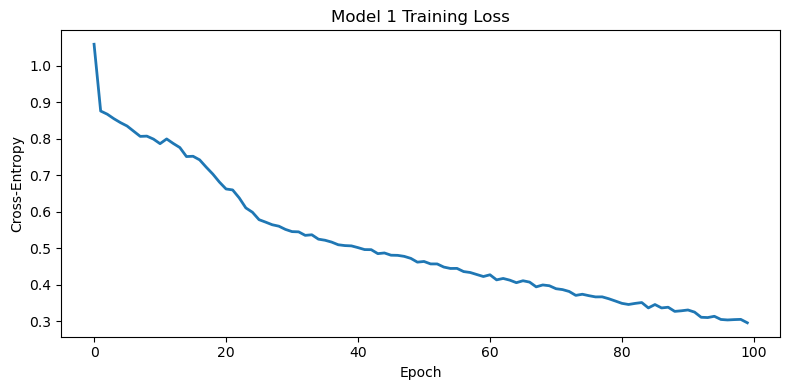

Saved model: artifacts/lstm_model1.pt


In [27]:
# Model 1 - train

history = train_model(
    model,
    train_loader,
    np.asarray(y)[train_idx],
    lr=config["lr"],
    weight_decay=config["weight_decay"],
)

checkpoint = {
    "state_dict": model.state_dict(),
    "classes": classes,
    "train_idx": train_idx,
    "test_idx": test_idx,
    "history": history,
    "sequence_length": SEQ_LEN,
    "config": config,
}
torch.save(checkpoint, config["model_path"])

plt.figure(figsize=(8, 4))
plt.plot(history, linewidth=2)
plt.title(f"{config['label']} Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.tight_layout()
plt.show()

print(f"Saved model: {config['model_path']}")

Accuracy: 0.7147
Balanced accuracy: 0.7588

Classification report:
                  precision    recall  f1-score   support

       confirmed       0.53      0.88      0.66       395
eclipsing binary       0.93      0.91      0.92       640
 false positives       0.74      0.46      0.57       914
  variable stars       0.67      0.79      0.73       596

        accuracy                           0.71      2545
       macro avg       0.72      0.76      0.72      2545
    weighted avg       0.74      0.71      0.71      2545



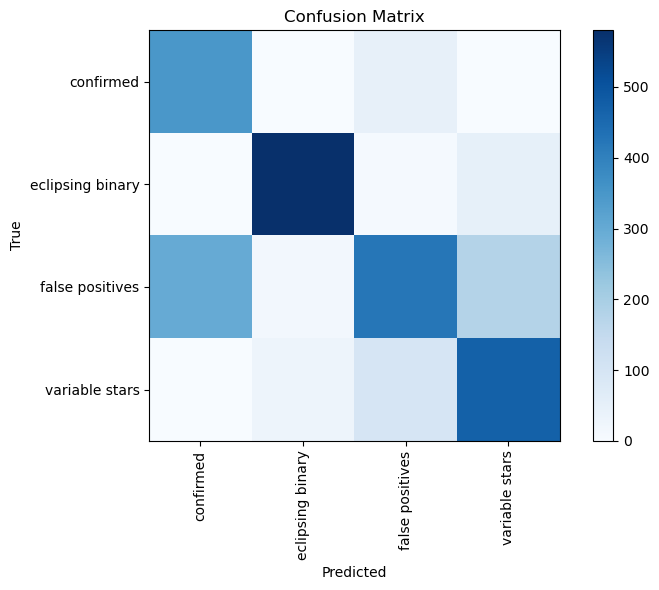

Saved predictions: artifacts/test_predictions_lstm_model1.csv
     dataset  object_id             label        true_label        pred_label
0        c00  202068470   false positives   false positives   false positives
1        koi    3329985   false positives   false positives         confirmed
2  villanova    2708614  eclipsing binary  eclipsing binary  eclipsing binary
3        c00  202085833   false positives   false positives   false positives
4        c00  202066196    variable stars    variable stars    variable stars


In [28]:
# Model 1 - evaluate

checkpoint = torch.load(config["model_path"], map_location=DEVICE)
model = instantiate_lstm(checkpoint["config"], num_classes=len(checkpoint["classes"]))
model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)

eval_result = evaluate_model(
    model,
    test_loader,
    checkpoint["classes"],
    meta,
    np.asarray(checkpoint["test_idx"]),
    checkpoint["config"]["predictions_path"],
)
results.append({**checkpoint["config"], **eval_result})

In [29]:
# Model 2 - definition

config = EXPERIMENT_CONFIGS[1]
print(config)
model = instantiate_lstm(config, num_classes=len(classes))
model

{'name': 'model2', 'label': 'Model 2', 'hidden_size': 128, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 5e-05, 'model_path': PosixPath('artifacts/lstm_model2.pt'), 'predictions_path': PosixPath('artifacts/test_predictions_lstm_model2.csv')}


LSTMClassifier(
  (lstm): LSTM(1, 128, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)

Epoch 01/100 - loss=1.0294
Epoch 02/100 - loss=0.7955
Epoch 03/100 - loss=0.7768
Epoch 04/100 - loss=0.7571
Epoch 05/100 - loss=0.7375
Epoch 06/100 - loss=0.7298
Epoch 07/100 - loss=0.7031
Epoch 08/100 - loss=0.6926
Epoch 09/100 - loss=0.6810
Epoch 10/100 - loss=0.6685
Epoch 11/100 - loss=0.6528
Epoch 12/100 - loss=0.6461
Epoch 13/100 - loss=0.6364
Epoch 14/100 - loss=0.6266
Epoch 15/100 - loss=0.6122
Epoch 16/100 - loss=0.5840
Epoch 17/100 - loss=0.5780
Epoch 18/100 - loss=0.5643
Epoch 19/100 - loss=0.5579
Epoch 20/100 - loss=0.5527
Epoch 21/100 - loss=0.5430
Epoch 22/100 - loss=0.5496
Epoch 23/100 - loss=0.5349
Epoch 24/100 - loss=0.5369
Epoch 25/100 - loss=0.5306
Epoch 26/100 - loss=0.5217
Epoch 27/100 - loss=0.5210
Epoch 28/100 - loss=0.5174
Epoch 29/100 - loss=0.5091
Epoch 30/100 - loss=0.5053
Epoch 31/100 - loss=0.4997
Epoch 32/100 - loss=0.4984
Epoch 33/100 - loss=0.4935
Epoch 34/100 - loss=0.4823
Epoch 35/100 - loss=0.4776
Epoch 36/100 - loss=0.4739
Epoch 37/100 - loss=0.4697
E

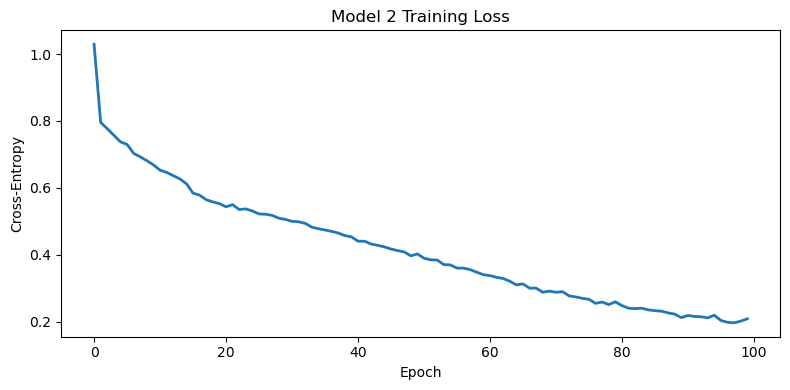

Saved model: artifacts/lstm_model2.pt


In [30]:
# Model 2 - train

history = train_model(
    model,
    train_loader,
    np.asarray(y)[train_idx],
    lr=config["lr"],
    weight_decay=config["weight_decay"],
)

checkpoint = {
    "state_dict": model.state_dict(),
    "classes": classes,
    "train_idx": train_idx,
    "test_idx": test_idx,
    "history": history,
    "sequence_length": SEQ_LEN,
    "config": config,
}
torch.save(checkpoint, config["model_path"])

plt.figure(figsize=(8, 4))
plt.plot(history, linewidth=2)
plt.title(f"{config['label']} Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.tight_layout()
plt.show()

print(f"Saved model: {config['model_path']}")

Accuracy: 0.7041
Balanced accuracy: 0.7191

Classification report:
                  precision    recall  f1-score   support

       confirmed       0.55      0.69      0.61       395
eclipsing binary       0.89      0.94      0.91       640
 false positives       0.66      0.55      0.60       914
  variable stars       0.68      0.69      0.69       596

        accuracy                           0.70      2545
       macro avg       0.70      0.72      0.70      2545
    weighted avg       0.71      0.70      0.70      2545



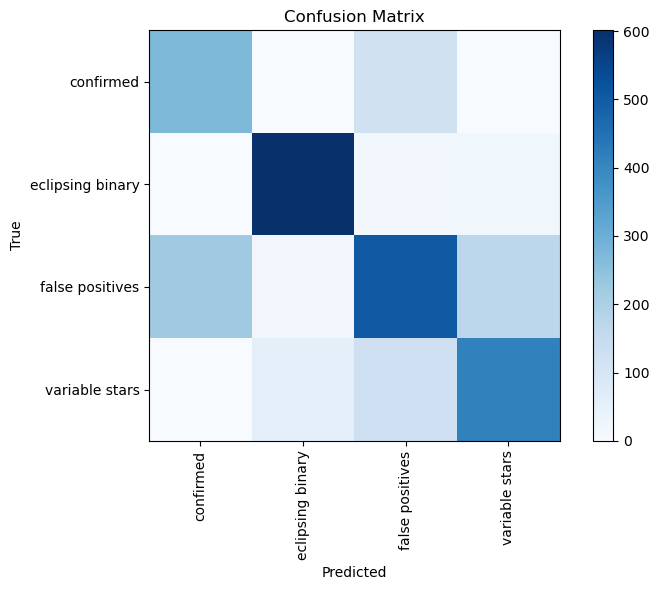

Saved predictions: artifacts/test_predictions_lstm_model2.csv
     dataset  object_id             label        true_label        pred_label
0        c00  202068470   false positives   false positives   false positives
1        koi    3329985   false positives   false positives         confirmed
2  villanova    2708614  eclipsing binary  eclipsing binary  eclipsing binary
3        c00  202085833   false positives   false positives   false positives
4        c00  202066196    variable stars    variable stars    variable stars


In [31]:
# Model 2 - evaluate

checkpoint = torch.load(config["model_path"], map_location=DEVICE)
model = instantiate_lstm(checkpoint["config"], num_classes=len(checkpoint["classes"]))
model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)

eval_result = evaluate_model(
    model,
    test_loader,
    checkpoint["classes"],
    meta,
    np.asarray(checkpoint["test_idx"]),
    checkpoint["config"]["predictions_path"],
)
results.append({**checkpoint["config"], **eval_result})

In [32]:
# Model 3 - definition

config = EXPERIMENT_CONFIGS[2]
print(config)
model = instantiate_lstm(config, num_classes=len(classes))
model

{'name': 'model3', 'label': 'Model 3', 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0007, 'weight_decay': 1e-05, 'model_path': PosixPath('artifacts/lstm_model3.pt'), 'predictions_path': PosixPath('artifacts/test_predictions_lstm_model3.csv')}


LSTMClassifier(
  (lstm): LSTM(1, 64, batch_first=True, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)

Epoch 01/100 - loss=1.0499
Epoch 02/100 - loss=0.8962
Epoch 03/100 - loss=0.8927
Epoch 04/100 - loss=0.8749
Epoch 05/100 - loss=0.8717
Epoch 06/100 - loss=0.8891
Epoch 07/100 - loss=0.8532
Epoch 08/100 - loss=0.8538
Epoch 09/100 - loss=0.8548
Epoch 10/100 - loss=0.8450
Epoch 11/100 - loss=0.8338
Epoch 12/100 - loss=0.8284
Epoch 13/100 - loss=0.8053
Epoch 14/100 - loss=0.8102
Epoch 15/100 - loss=0.8050
Epoch 16/100 - loss=0.7976
Epoch 17/100 - loss=0.8004
Epoch 18/100 - loss=0.7790
Epoch 19/100 - loss=0.7856
Epoch 20/100 - loss=0.7734
Epoch 21/100 - loss=0.7572
Epoch 22/100 - loss=0.7305
Epoch 23/100 - loss=0.7319
Epoch 24/100 - loss=0.7110
Epoch 25/100 - loss=0.7040
Epoch 26/100 - loss=0.7000
Epoch 27/100 - loss=0.6948
Epoch 28/100 - loss=0.6827
Epoch 29/100 - loss=0.6827
Epoch 30/100 - loss=0.6728
Epoch 31/100 - loss=0.6696
Epoch 32/100 - loss=0.6626
Epoch 33/100 - loss=0.6589
Epoch 34/100 - loss=0.6492
Epoch 35/100 - loss=0.6433
Epoch 36/100 - loss=0.6351
Epoch 37/100 - loss=0.6307
E

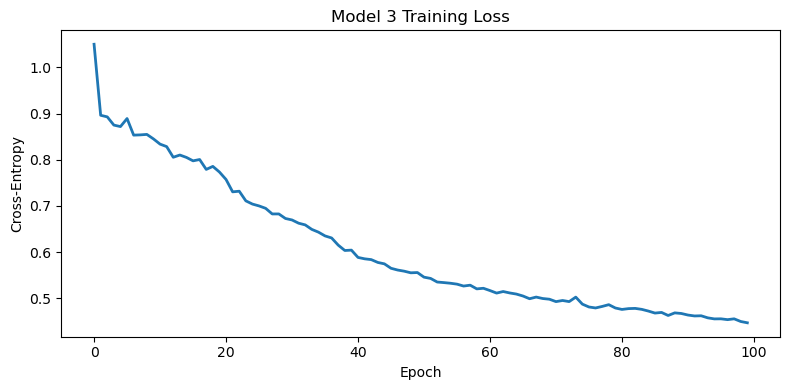

Saved model: artifacts/lstm_model3.pt


In [33]:
# Model 3 - train

history = train_model(
    model,
    train_loader,
    np.asarray(y)[train_idx],
    lr=config["lr"],
    weight_decay=config["weight_decay"],
)

checkpoint = {
    "state_dict": model.state_dict(),
    "classes": classes,
    "train_idx": train_idx,
    "test_idx": test_idx,
    "history": history,
    "sequence_length": SEQ_LEN,
    "config": config,
}
torch.save(checkpoint, config["model_path"])

plt.figure(figsize=(8, 4))
plt.plot(history, linewidth=2)
plt.title(f"{config['label']} Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.tight_layout()
plt.show()

print(f"Saved model: {config['model_path']}")

Accuracy: 0.7371
Balanced accuracy: 0.7814

Classification report:
                  precision    recall  f1-score   support

       confirmed       0.54      0.95      0.69       395
eclipsing binary       0.92      0.94      0.93       640
 false positives       0.75      0.51      0.61       914
  variable stars       0.75      0.72      0.74       596

        accuracy                           0.74      2545
       macro avg       0.74      0.78      0.74      2545
    weighted avg       0.76      0.74      0.73      2545



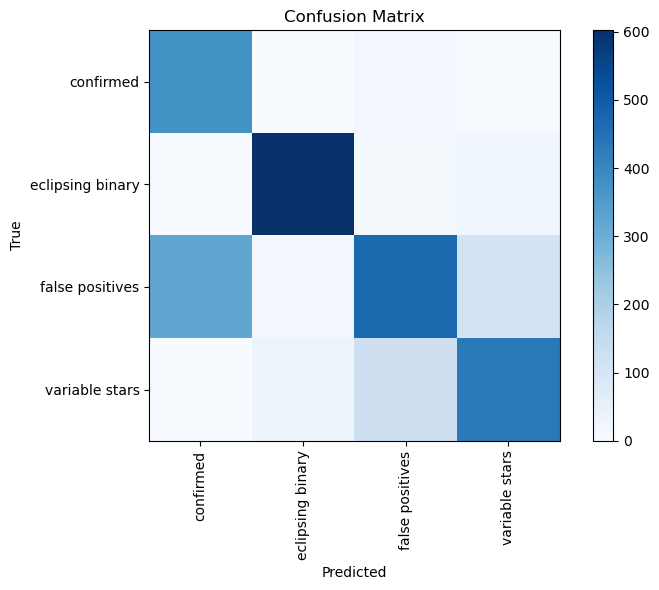

Saved predictions: artifacts/test_predictions_lstm_model3.csv
     dataset  object_id             label        true_label        pred_label
0        c00  202068470   false positives   false positives   false positives
1        koi    3329985   false positives   false positives         confirmed
2  villanova    2708614  eclipsing binary  eclipsing binary  eclipsing binary
3        c00  202085833   false positives   false positives   false positives
4        c00  202066196    variable stars    variable stars    variable stars


In [34]:
# Model 3 - evaluate

checkpoint = torch.load(config["model_path"], map_location=DEVICE)
model = instantiate_lstm(checkpoint["config"], num_classes=len(checkpoint["classes"]))
model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)

eval_result = evaluate_model(
    model,
    test_loader,
    checkpoint["classes"],
    meta,
    np.asarray(checkpoint["test_idx"]),
    checkpoint["config"]["predictions_path"],
)
results.append({**checkpoint["config"], **eval_result})

In [35]:
# Compare the three runs.

results_df = pd.DataFrame(results)
results_df = results_df[[
    "name",
    "label",
    "hidden_size",
    "num_layers",
    "dropout",
    "lr",
    "weight_decay",
    "accuracy",
    "balanced_accuracy",
    "model_path",
    "predictions_path",
]].sort_values(["balanced_accuracy", "accuracy"], ascending=False).reset_index(drop=True)
results_df

,name,label,hidden_size,num_layers,dropout,lr,weight_decay,accuracy,balanced_accuracy,model_path,predictions_path
0,model3,Model 3,64,1,0.1,0.0007,0.00001,0.737132,0.781441,artifacts/lstm_model3.pt,artifacts/test_predictions_lstm_model3.csv
1,model1,Model 1,96,2,0.2,0.0005,0.00010,0.714735,0.758757,artifacts/lstm_model1.pt,artifacts/test_predictions_lstm_model1.csv
2,model2,Model 2,128,3,0.3,0.0003,0.00005,0.704126,0.719131,artifacts/lstm_model2.pt,artifacts/test_predictions_lstm_model2.csv
